In [56]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [57]:
#define state
class BMIState(TypedDict):
    
    weight_kg: float
    height_m: float
    bmi : float
    category: str
    

In [58]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
   
    return state

In [59]:
def add_label(state:BMIState) -> BMIState:
    if state['bmi'] <18.5:
        state['category']=  "Underweight"
    elif state['bmi']>24.9:
        state['category']=  "Overweight"
    else:
        state['category']=  "Normal"
        
    return state

In [60]:
graph = StateGraph(BMIState)

#add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label',add_label)

#add edges to graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label')
graph.add_edge('label',END)

#compile the graph
workflow = graph.compile()


In [61]:
#execute the graph
initial_state = {
    'weight_kg': 54,
    'height_m': 1.575
}
output_state = workflow.invoke(initial_state)

print(output_state)


{'weight_kg': 54, 'height_m': 1.575, 'bmi': 21.77, 'category': 'Normal'}


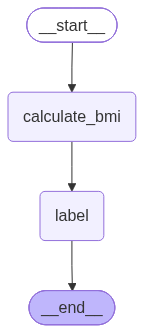

In [62]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())